# Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
from scipy.stats import chi2_contingency

# Load Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("cvd_dataset.csv")

Saving cvd_dataset.csv to cvd_dataset.csv


# Display Dataset

In [ ]:
df.head()

df.info()

df.describe()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   object 
 1   Age                           1451 non-null   float64
 2   Weight (kg)                   1448 non-null   float64
 3   Height (m)                    1462 non-null   float64
 4   BMI                           1465 non-null   float64
 5   Abdominal Circumference (cm)  1462 non-null   float64
 6   Blood Pressure (mmHg)         1529 non-null   object 
 7   Total Cholesterol (mg/dL)     1456 non-null   float64
 8   HDL (mg/dL)                   1449 non-null   float64
 9   Fasting Blood Sugar (mg/dL)   1462 non-null   float64
 10  Smoking Status                1529 non-null   object 
 11  Diabetes Status               1529 non-null   object 
 12  Physical Activity Level       1529 non-null   object 
 13  Fam

(1529, 22)

# Data Cleaning

Finding Null Values

In [ ]:
df.isnull().sum()

# Finding which percent of values make up the nulls
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percent Missing": missing_percent
})

missing_table.sort_values("Percent Missing", ascending=False)

,Missing Values,Percent Missing
Diastolic BP,82,5.362982
Weight (kg),81,5.297580
HDL (mg/dL),80,5.232178
Waist-to-Height Ratio,79,5.166776
Age,78,5.101373
Height (cm),74,4.839765
Total Cholesterol (mg/dL),73,4.774362
Systolic BP,71,4.643558
CVD Risk Score,70,4.578156
Estimated LDL (mg/dL),69,4.512753


In [ ]:
# Filling up missing values using calculations and imputations
df_clean=df.copy()

# Height (cm)
mask = (
    df_clean["Height (cm)"].isna() &
    df_clean["Height (m)"].notna()
)

df_clean.loc[mask, "Height (cm)"] = (
    df_clean.loc[mask, "Height (m)"] * 100
)


# Height (m)
mask = (
    df_clean["Height (m)"].isna() &
    df_clean["Height (cm)"].notna()
)

df_clean.loc[mask, "Height (m)"] = (
    df_clean.loc[mask, "Height (cm)"] / 100
)


# BMI
mask = (
    df_clean["BMI"].isna() &
    df_clean["Weight (kg)"].notna() &
    df_clean["Height (m)"].notna()
)

df_clean.loc[mask, "BMI"] = (
    df_clean.loc[mask, "Weight (kg)"] /
    (df_clean.loc[mask, "Height (m)"] ** 2)
)


# Remaining Numerical Columns
numerical_columns = [
    "Age",
    "Weight (kg)",
    "HDL (mg/dL)",
    "Waist-to-Height Ratio",
    "Total Cholesterol (mg/dL)",
    "Systolic BP",
    "Diastolic BP",
    "Estimated LDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Abdominal Circumference (cm)"
]

for column in numerical_columns:
    median = df_clean[column].median()
    df_clean[column] = df_clean[column].fillna(median)


# Fill Categorical Variables
categorical_columns = [
    "Sex",
    "Smoking Status",
    "Diabetes Status",
    "Physical Activity Level",
    "Family History of CVD",
    "Blood Pressure Category"
]

for column in categorical_columns:
    mode = df_clean[column].mode()[0]
    df_clean[column] = df_clean[column].fillna(mode)


# Handle Target Columns
df_clean = df_clean.dropna(subset=["CVD Risk Level"])

In [ ]:
# Verify Cleanliness
df_clean.isnull().sum()

,0
Sex,0
Age,0
Weight (kg),0
Height (m),6
BMI,5
Abdominal Circumference (cm),0
Blood Pressure (mmHg),0
Total Cholesterol (mg/dL),0
HDL (mg/dL),0
Fasting Blood Sugar (mg/dL),0


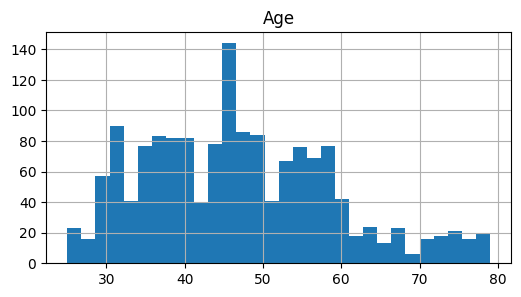

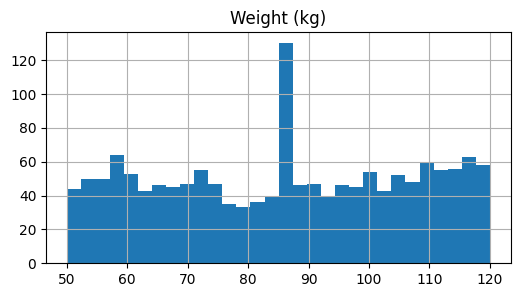

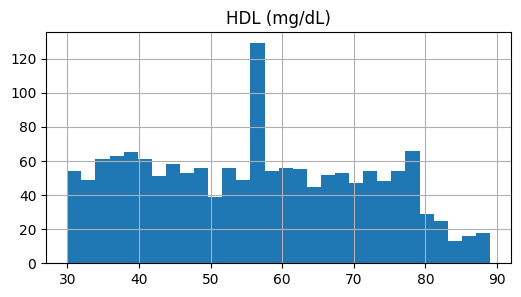

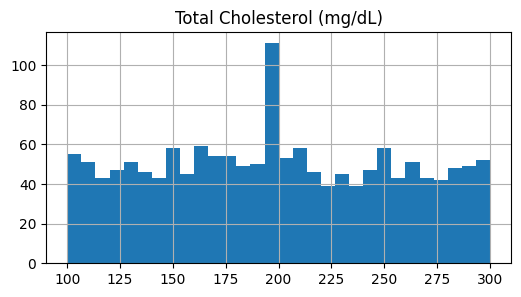

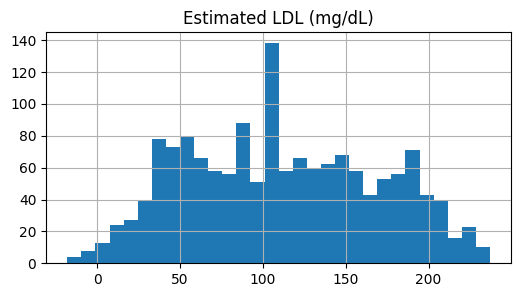

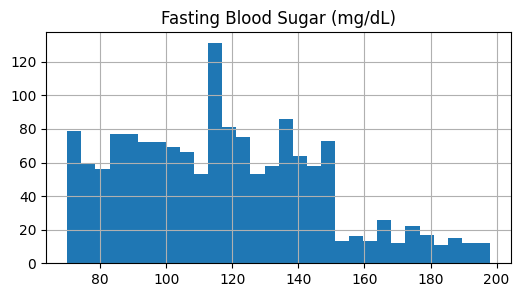

In [ ]:
# Checking Distributions
numerical_columns = [
    "Age",
    "Weight (kg)",
    "HDL (mg/dL)",
    "Total Cholesterol (mg/dL)",
    "Estimated LDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)"
]

for column in numerical_columns:
    plt.figure(figsize=(6, 3))
    df_clean[column].hist(bins=30)
    plt.title(column)
    plt.show()

Checking for Duplicate Values

In [ ]:
df.duplicated().sum()

np.int64(0)

Check Data Types

In [ ]:
df.dtypes

,0
Sex,object
Age,float64
Weight (kg),float64
Height (m),float64
BMI,float64
Abdominal Circumference (cm),float64
Blood Pressure (mmHg),object
Total Cholesterol (mg/dL),float64
HDL (mg/dL),float64
Fasting Blood Sugar (mg/dL),float64


Check for Outliers

<Axes: xlabel='Fasting Blood Sugar (mg/dL)'>

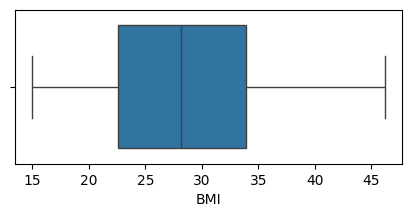

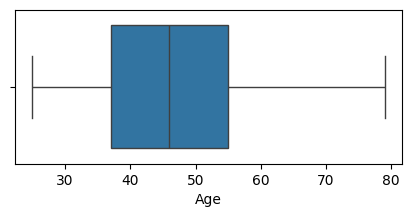

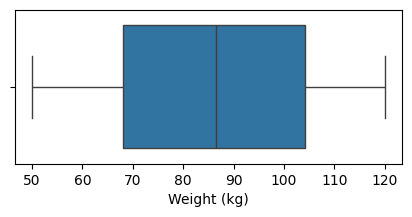

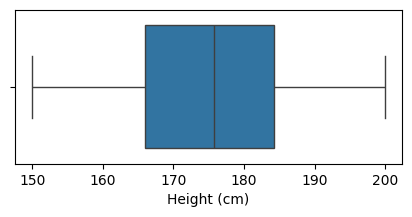

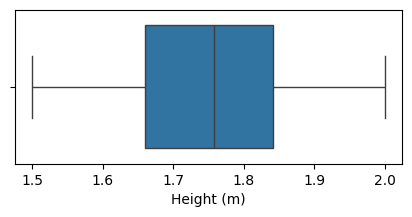

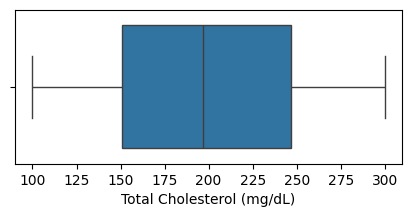

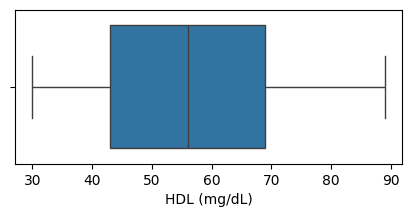

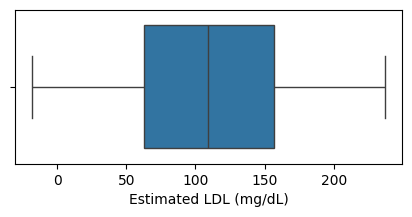

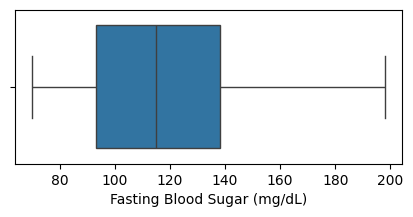

In [ ]:
# BMI Outliers
plt.figure(figsize=(5, 2))
sns.boxplot(x=df_clean["BMI"])

# Age Outliers
plt.figure(figsize=(5, 2))
sns.boxplot(x=df_clean['Age'])

# Weight Outliers
plt.figure(figsize=(5, 2))
sns.boxplot(x=df_clean['Weight (kg)'])

# Height (cm) Outliers
plt.figure(figsize=(5, 2))
sns.boxplot(x=df_clean['Height (cm)'])

# Height (m) Outliers
plt.figure(figsize=(5, 2))
sns.boxplot(x=df_clean['Height (m)'])

# Cholesterol Outliers
plt.figure(figsize=(5, 2))
sns.boxplot(x=df_clean['Total Cholesterol (mg/dL)'])

# HDL Outliers
plt.figure(figsize=(5, 2))
sns.boxplot(x=df_clean['HDL (mg/dL)'])

# Estimated LDL Outliers
plt.figure(figsize=(5, 2))
sns.boxplot(x=df_clean['Estimated LDL (mg/dL)'])

# Blood Sugar Outliers
plt.figure(figsize=(5, 2))
sns.boxplot(x=df_clean['Fasting Blood Sugar (mg/dL)'])


Remaining Outlier Checks

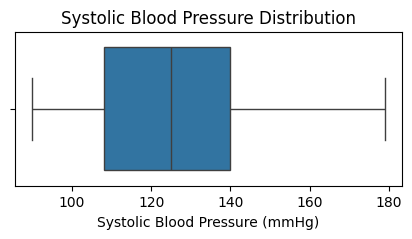

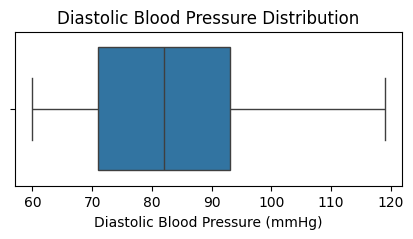

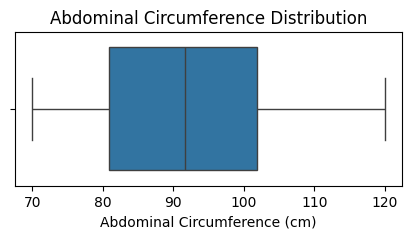

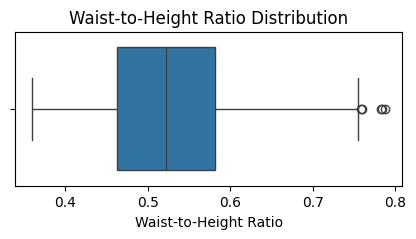

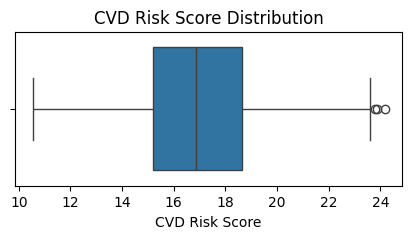

In [ ]:
# Systolic Blood Pressure Outliers
plt.figure(figsize=(5, 2))

sns.boxplot(x=df_clean["Systolic BP"])

plt.title("Systolic Blood Pressure Distribution")
plt.xlabel("Systolic Blood Pressure (mmHg)")

plt.show()


# Diastolic Blood Pressure Outliers
plt.figure(figsize=(5, 2))

sns.boxplot(x=df_clean["Diastolic BP"])

plt.title("Diastolic Blood Pressure Distribution")
plt.xlabel("Diastolic Blood Pressure (mmHg)")

plt.show()


# Abdominal Circumference Outliers
plt.figure(figsize=(5, 2))

sns.boxplot(x=df_clean["Abdominal Circumference (cm)"])

plt.title("Abdominal Circumference Distribution")
plt.xlabel("Abdominal Circumference (cm)")

plt.show()


# Waist-to-Height Ratio Outliers
plt.figure(figsize=(5, 2))

sns.boxplot(x=df_clean["Waist-to-Height Ratio"])

plt.title("Waist-to-Height Ratio Distribution")
plt.xlabel("Waist-to-Height Ratio")

plt.show()


# CVD Risk Score Outliers
plt.figure(figsize=(5, 2))

sns.boxplot(x=df_clean["CVD Risk Score"])

plt.title("CVD Risk Score Distribution")
plt.xlabel("CVD Risk Score")

plt.show()

Validate Clinical Values

In [ ]:
# Checking if age is <18 and >100
print("Age < 18:", len(df[df["Age"] < 18]))
print("Age > 100:", len(df[df["Age"] > 100]))

# Checking if BMI <10
print("BMI < 10:", len(df[df["BMI"] < 10]))

# Checking if HDL is negative
print("HDL < 0:", len(df[df["HDL (mg/dL)"] < 0]))

# Checking if Fasting Blood Sugar is negative
print("FBS < 0:", len(df[df["Fasting Blood Sugar (mg/dL)"] < 0]))

# Checking if Blood Pressure is negative
print("Systolic BP < 0:", len(df[df["Systolic BP"] < 0]))
print("Diastolic BP < 0:", len(df[df["Diastolic BP"] < 0]))

Age < 18: 0
Age > 100: 0
BMI < 10: 0
HDL < 0: 0
FBS < 0: 0
Systolic BP < 0: 0
Diastolic BP < 0: 0


# Exploratory Data Analysis

Patient Demographics

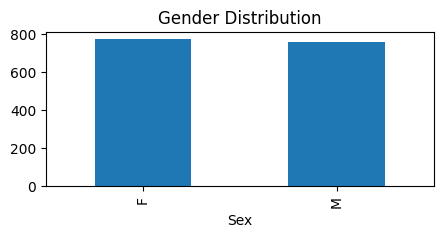

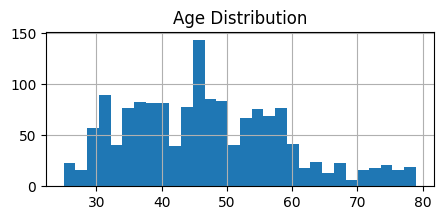

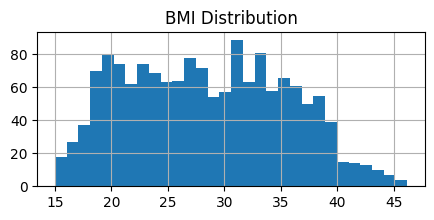

In [ ]:
# Gender Distribution
plt.figure(figsize=(5, 2))
df_clean["Sex"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()

# Age Distribution
plt.figure(figsize=(5, 2))
df_clean["Age"].hist(bins=30)
plt.title("Age Distribution")
plt.show()

# BMI Distribution
plt.figure(figsize=(5, 2))
df_clean["BMI"].hist(bins=30)
plt.title("BMI Distribution")
plt.show()

Disease Distribution

<Axes: xlabel='CVD Risk Level', ylabel='count'>

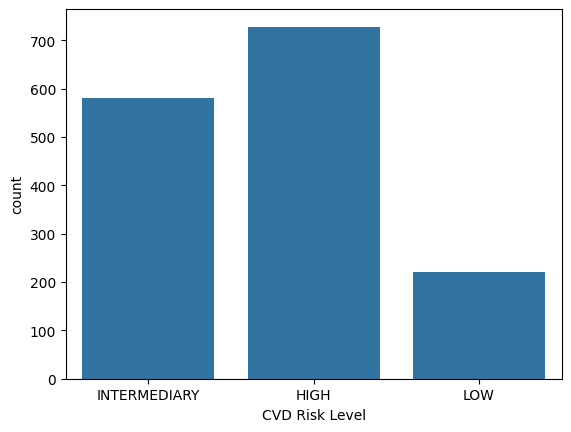

In [ ]:
sns.countplot(x='CVD Risk Level', data=df)

Clinical Factors (Numerical)

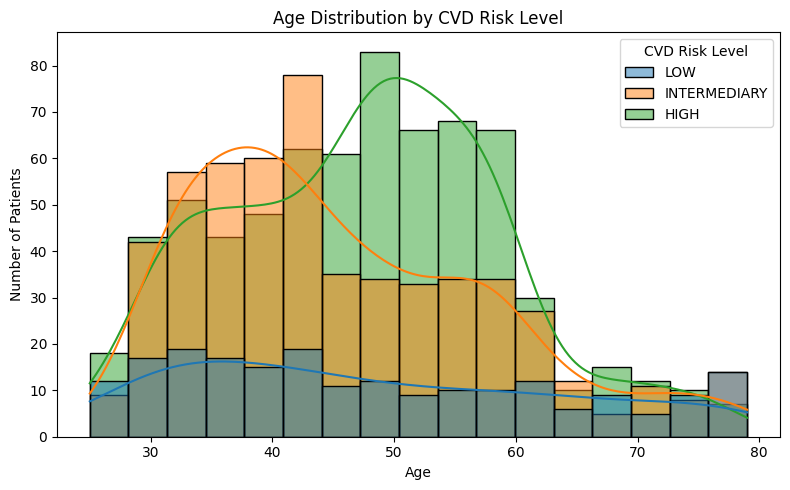

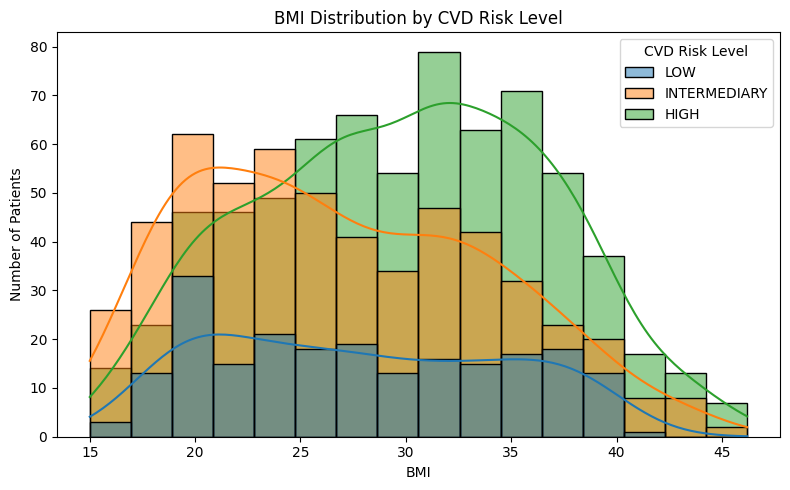

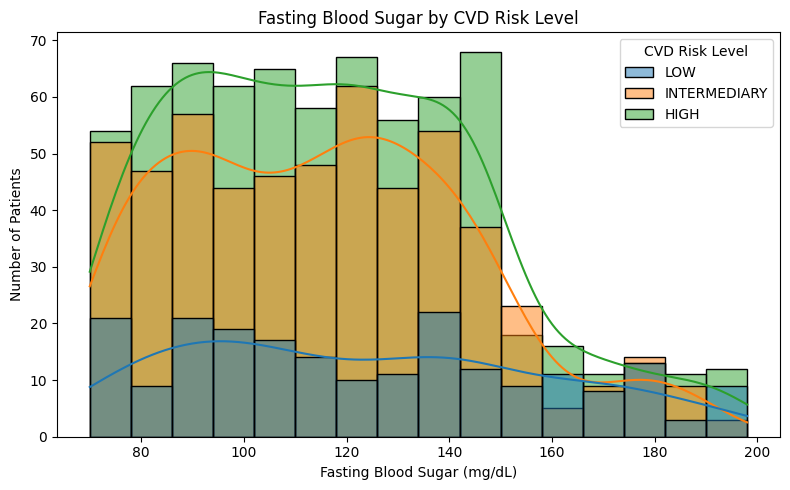

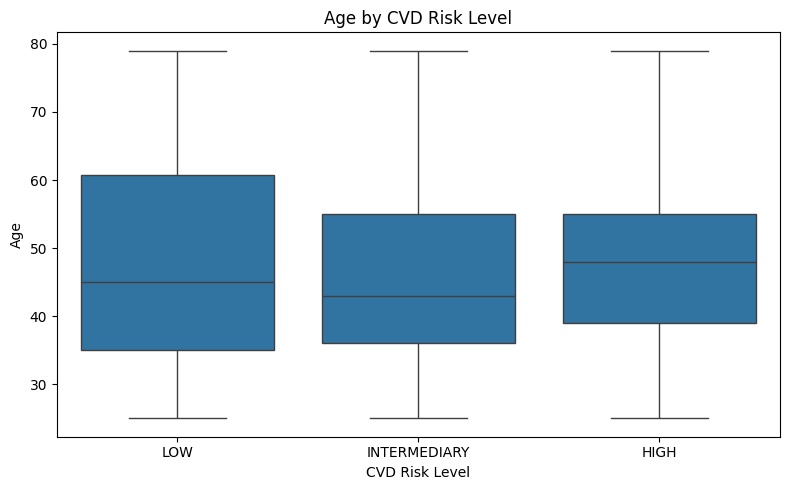

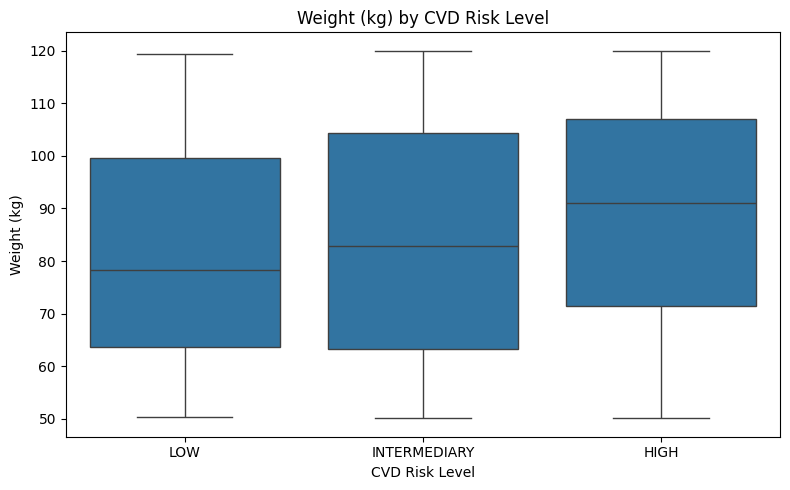

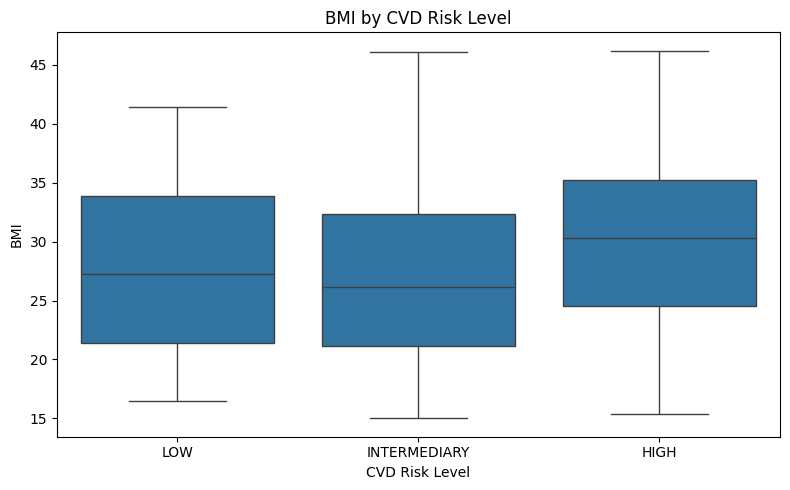

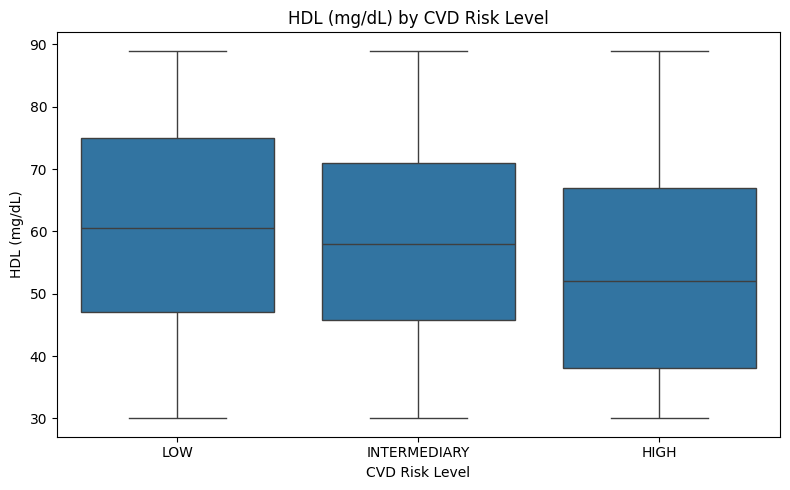

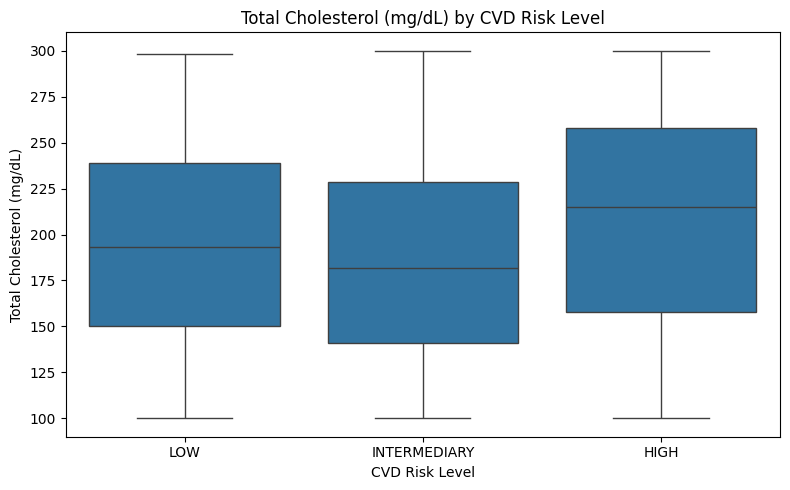

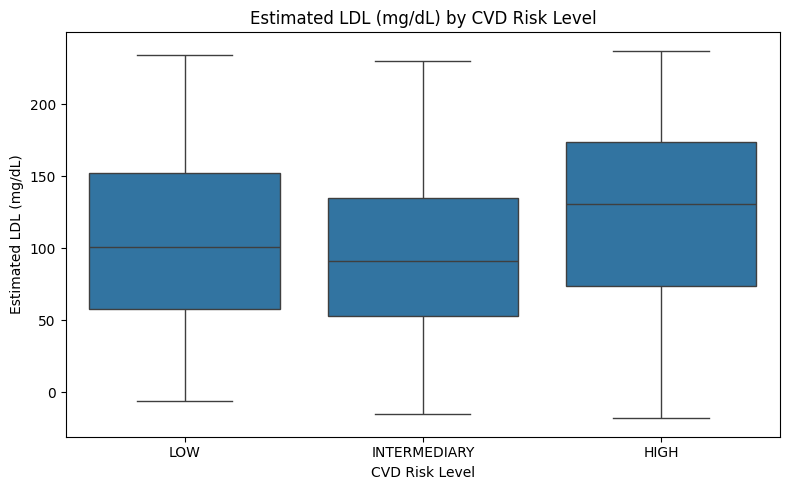

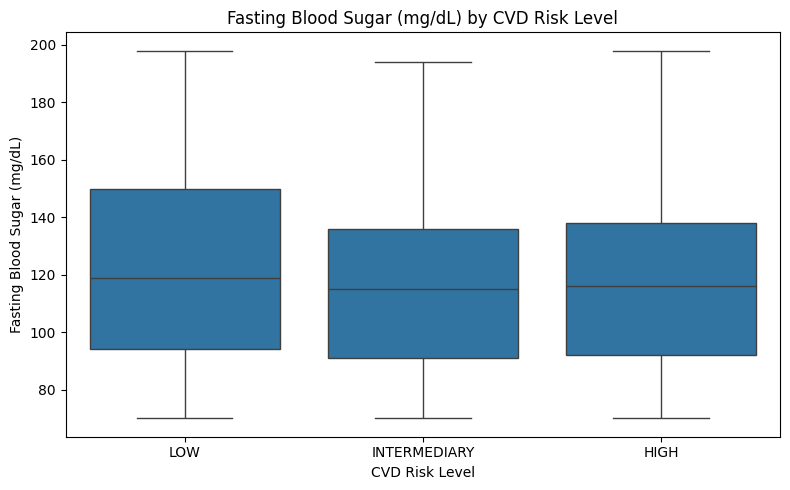

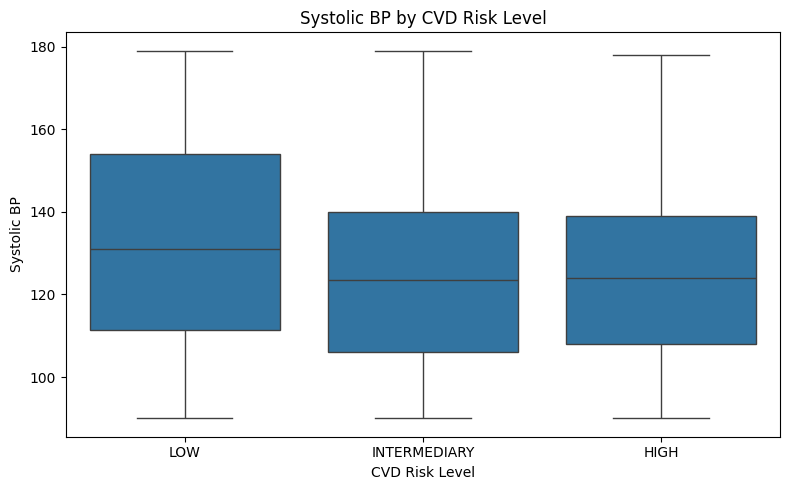

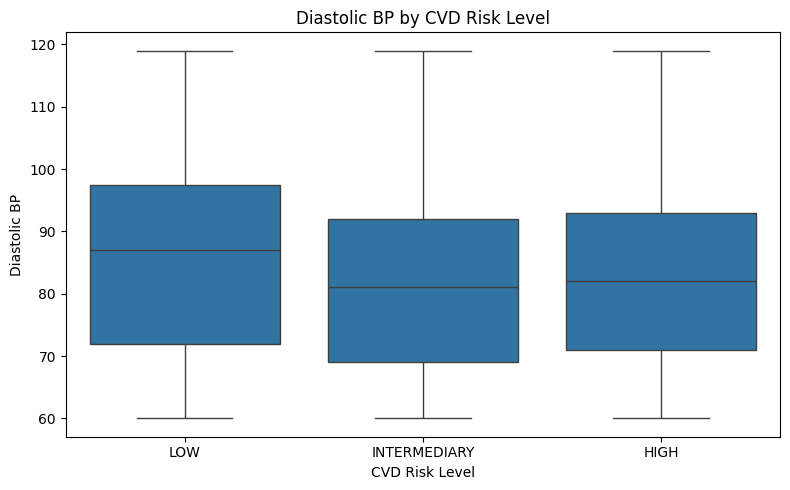

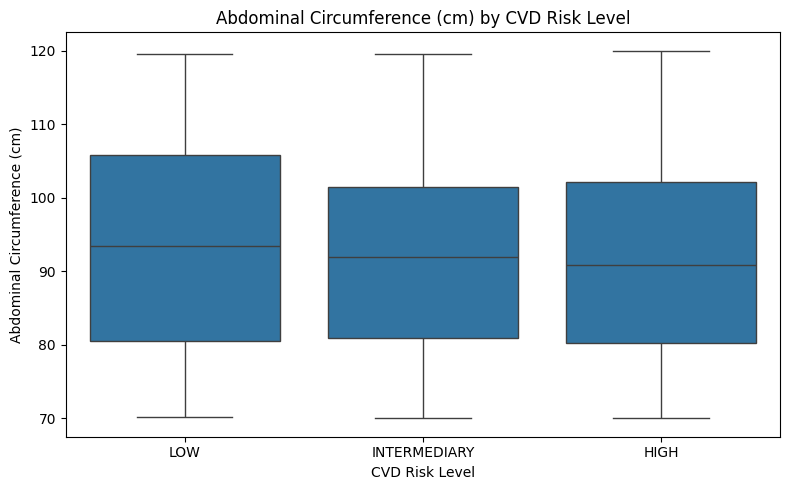

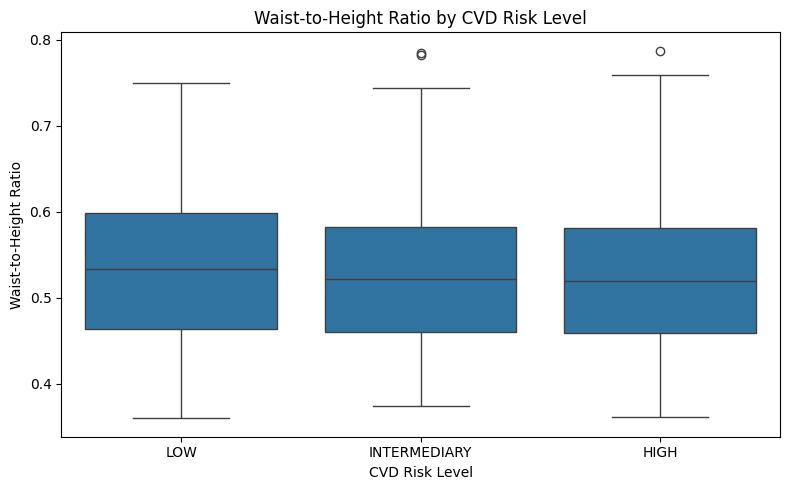

In [ ]:
risk_order = ["LOW", "INTERMEDIARY", "HIGH"]

numerical_features = [
    "Age",
    "Weight (kg)",
    "BMI",
    "HDL (mg/dL)",
    "Total Cholesterol (mg/dL)",
    "Estimated LDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Systolic BP",
    "Diastolic BP",
    "Abdominal Circumference (cm)",
    "Waist-to-Height Ratio"
]

# Histogram for age
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    hue="CVD Risk Level",
    hue_order=risk_order,
    kde=True
)

plt.title("Age Distribution by CVD Risk Level")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

# Histogram for BMI
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="BMI",
    hue="CVD Risk Level",
    hue_order=risk_order,
    kde=True
)

plt.title("BMI Distribution by CVD Risk Level")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()


# Fasting Blood Sugar Histogram
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Fasting Blood Sugar (mg/dL)",
    hue="CVD Risk Level",
    hue_order=risk_order,
    kde=True
)

plt.title("Fasting Blood Sugar by CVD Risk Level")
plt.xlabel("Fasting Blood Sugar (mg/dL)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()



# Boxplots for numerical features
for feature in numerical_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="CVD Risk Level",
        y=feature,
        order=risk_order
    )

    plt.title(f"{feature} by CVD Risk Level")
    plt.xlabel("CVD Risk Level")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

Clinical Factors (Categorical)

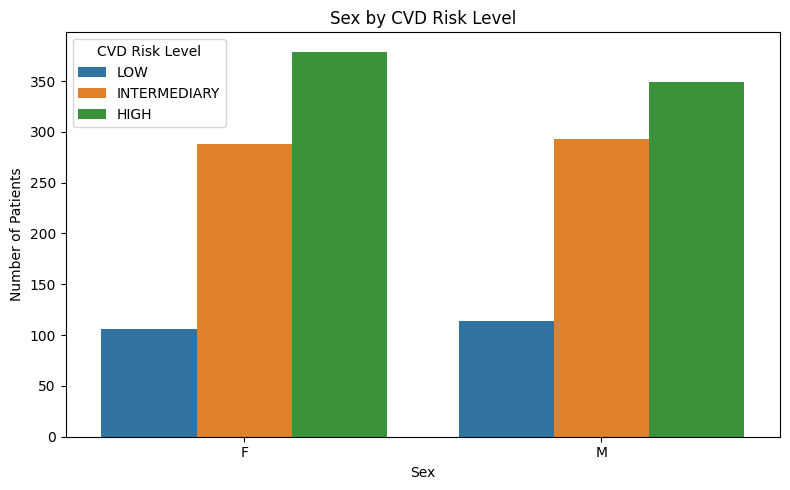

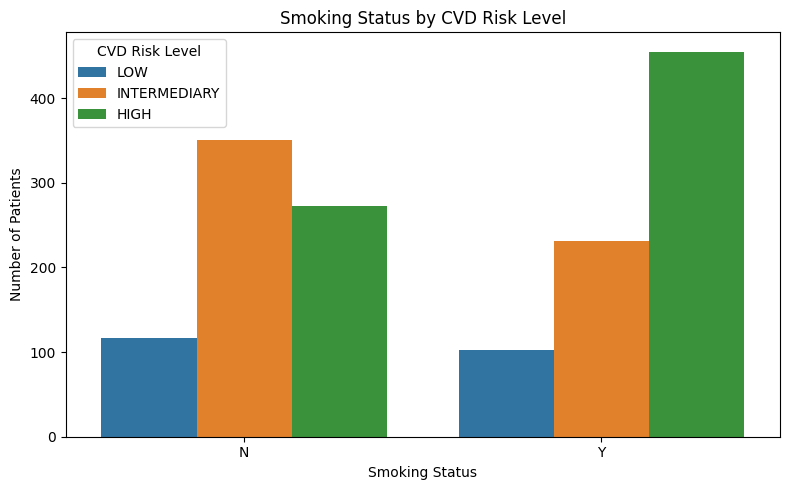

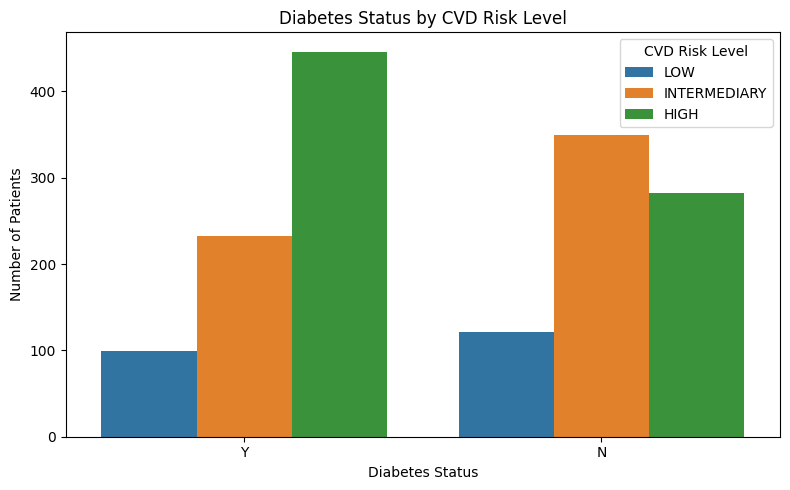

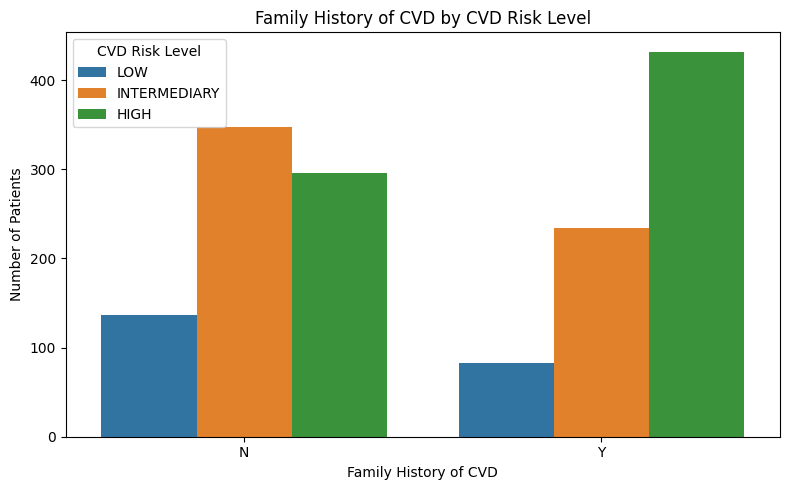

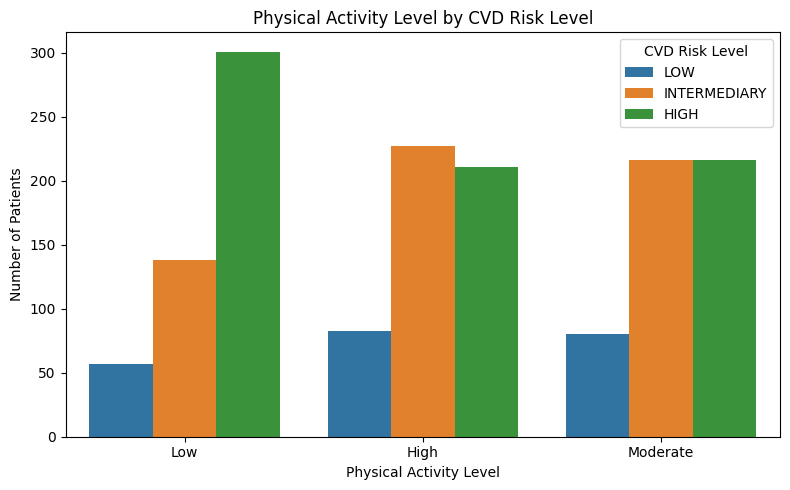

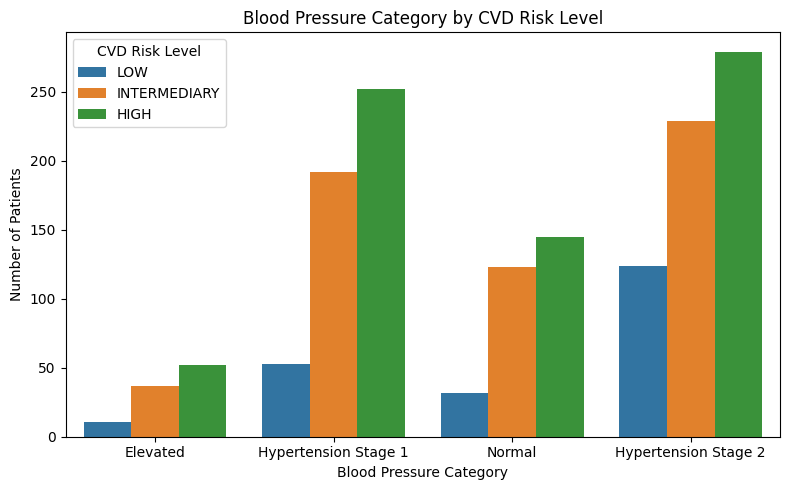

In [ ]:
risk_order = ["LOW", "INTERMEDIARY", "HIGH"]

categorical_features = [
    "Sex",
    "Smoking Status",
    "Diabetes Status",
    "Family History of CVD",
    "Physical Activity Level",
    "Blood Pressure Category"
]

for feature in categorical_features:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=feature,
        hue="CVD Risk Level",
        hue_order=risk_order
    )

    plt.title(f"{feature} by CVD Risk Level")
    plt.xlabel(feature)
    plt.ylabel("Number of Patients")

    plt.tight_layout()
    plt.show()

Correlation Matrix

<Axes: >

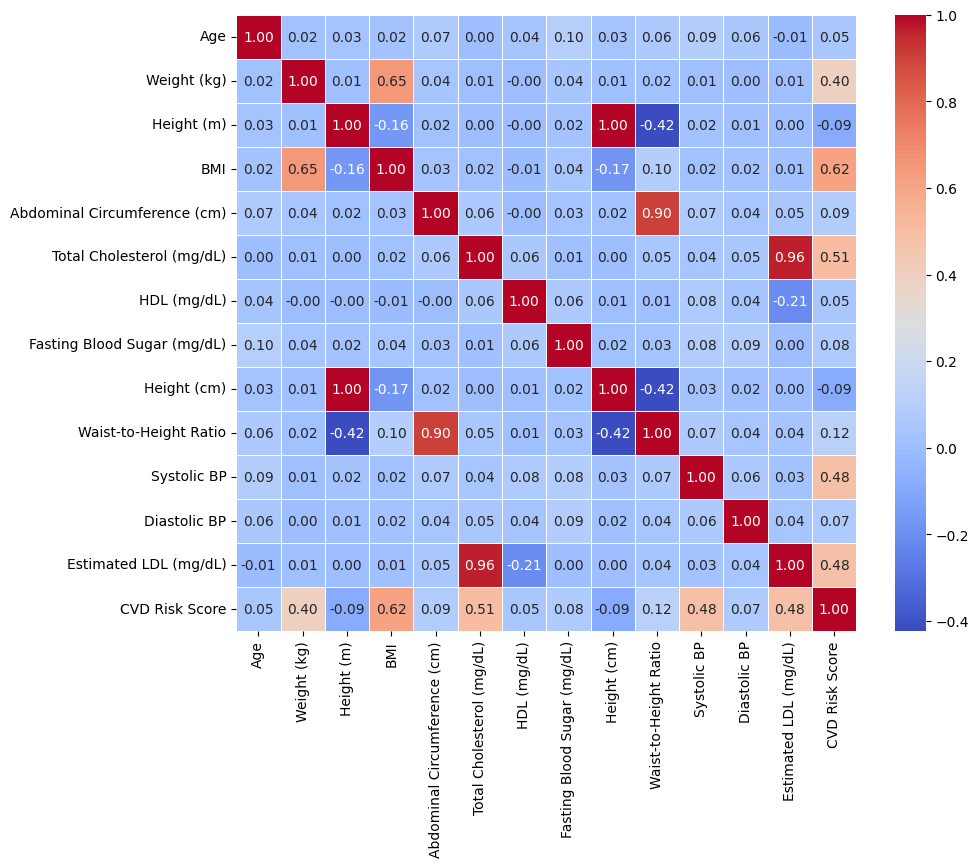

In [ ]:
plt.figure(figsize=(10, 8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",          # Show 2 decimal places
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 10}
)

# Feature Engineering

Encode Categorical Variables

In [ ]:
encoder = LabelEncoder()

categorical_columns = [
    "Sex",
    "Smoking Status",
    "Diabetes Status",
    "Physical Activity Level",
    "Family History of CVD",
    "Blood Pressure Category",
    "CVD Risk Level",
]

df_clean[categorical_columns] = df_clean[categorical_columns].apply(encoder.fit_transform)

Feature Selection

In [ ]:
target = 'CVD Risk Level'

# Remove target from features
X = df_clean.drop(columns=[target])
y = df_clean[target]

# Exclude CVD Risk Score from predictor set
X = X.drop(columns=["CVD Risk Score"])

# Exclude Height (cm) and Blood Pressure (mmHg) from predictor set
X = X.drop(
    columns=[
        "Height (cm)",
        "Blood Pressure (mmHg)"
    ]
)

print(X.columns.tolist())

['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Blood Pressure Category', 'Estimated LDL (mg/dL)']


In [ ]:
# Exclude Blood Pressure Category from predictor set
X = X.drop(columns=["Blood Pressure Category"])
print(X.columns.tolist())

['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)']


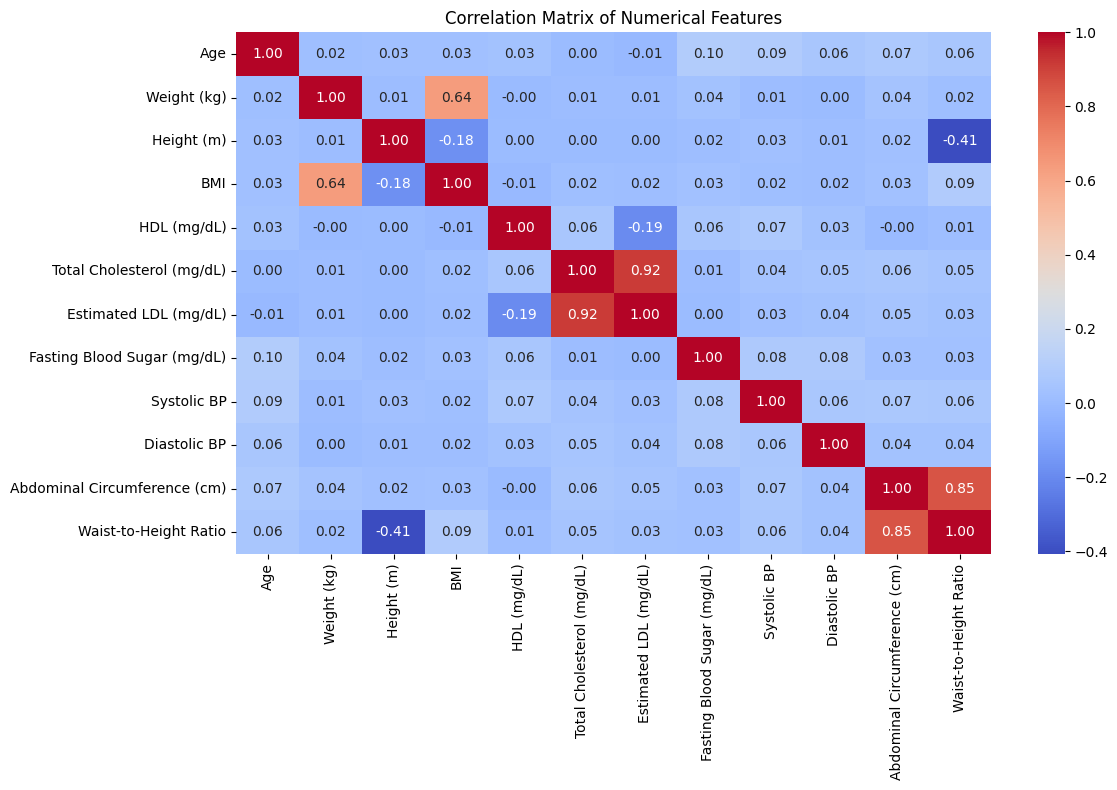

In [ ]:
# Check for correlations
numerical_features = [
    "Age",
    "Weight (kg)",
    "Height (m)",
    "BMI",
    "HDL (mg/dL)",
    "Total Cholesterol (mg/dL)",
    "Estimated LDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Systolic BP",
    "Diastolic BP",
    "Abdominal Circumference (cm)",
    "Waist-to-Height Ratio"
]

correlation_matrix = df_clean[numerical_features].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

Analyze Updated Numerical features against targets

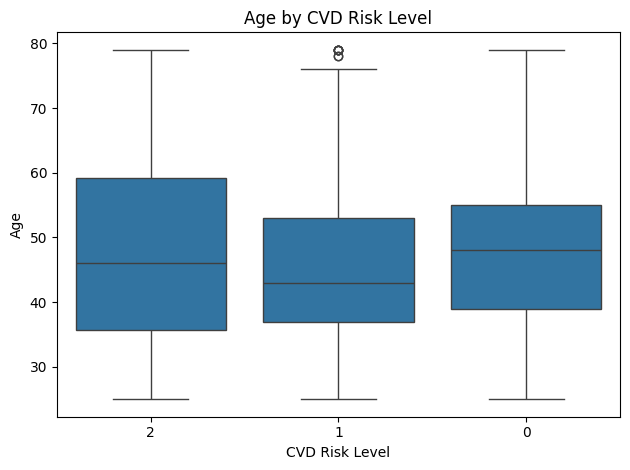

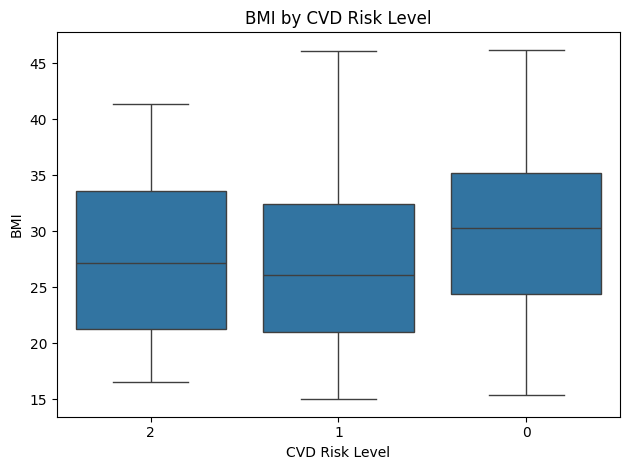

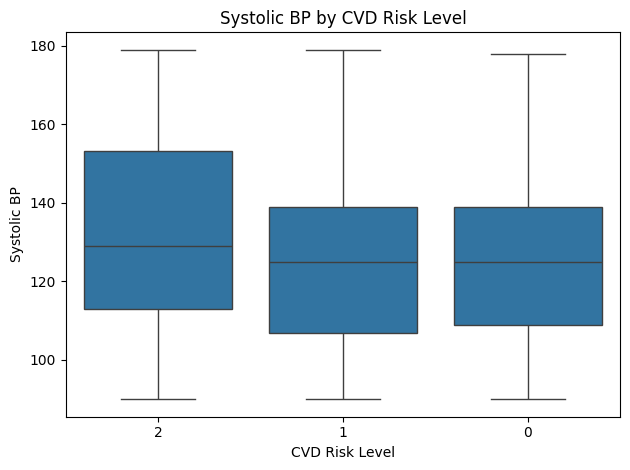

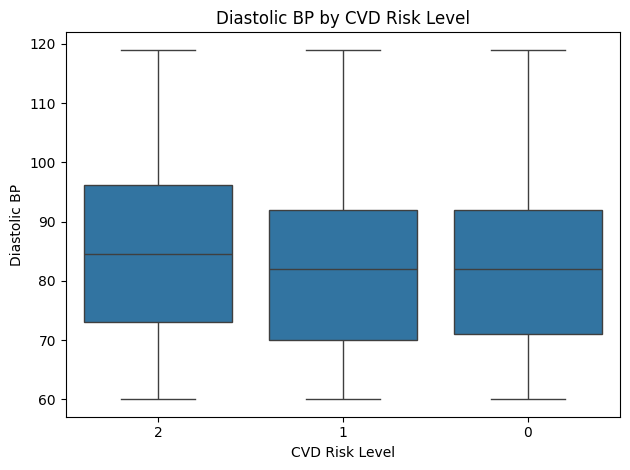

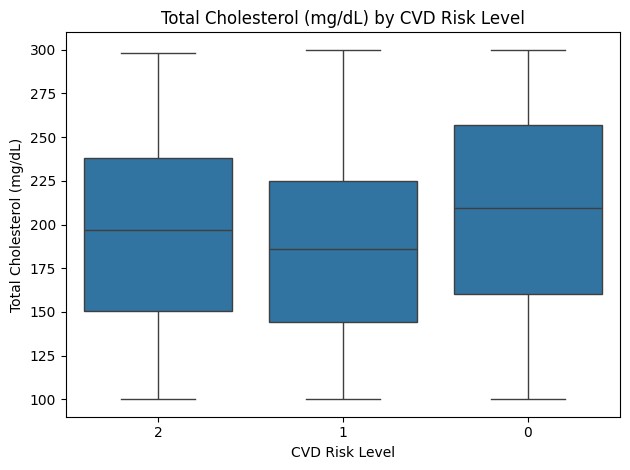

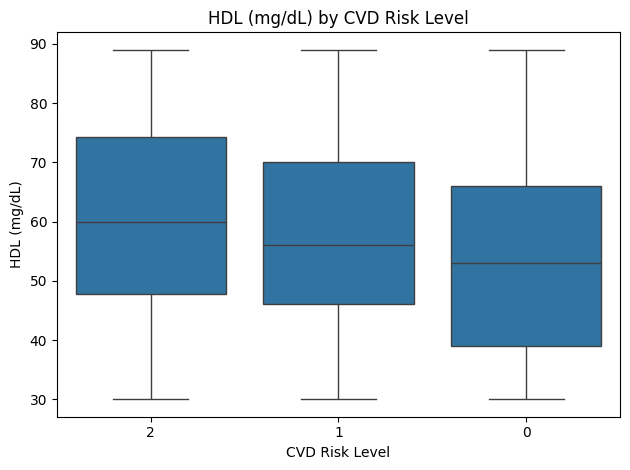

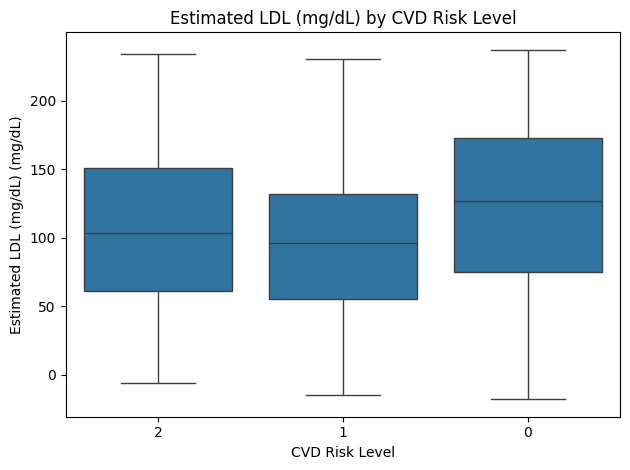

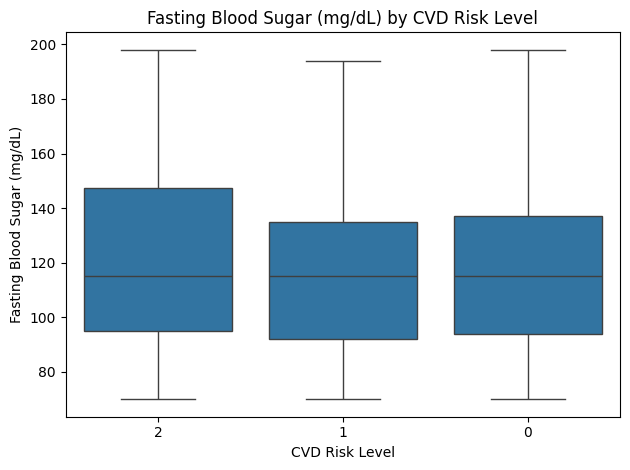

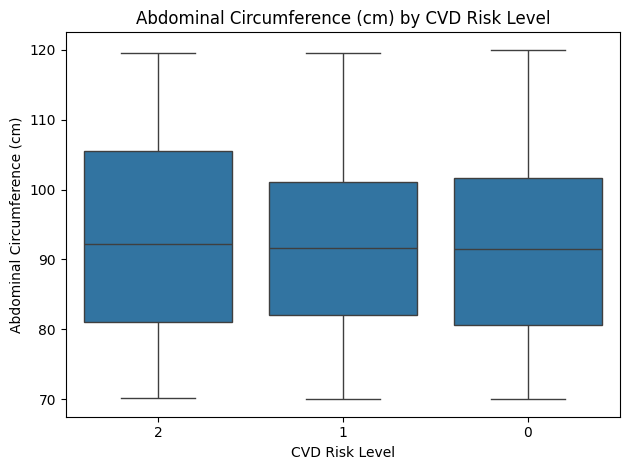

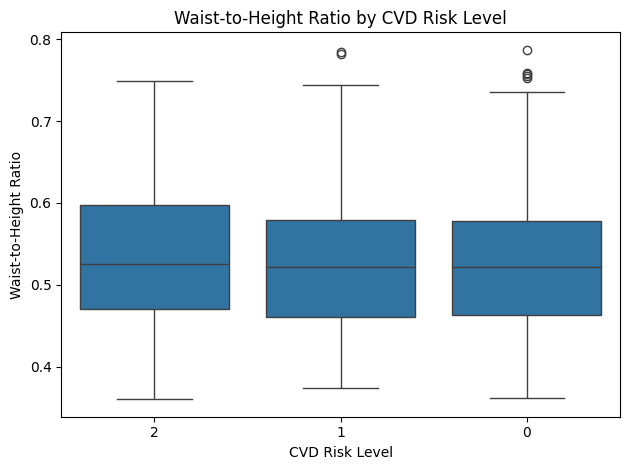

In [ ]:
# Age by CVD Risk Level

sns.boxplot(
    data=df_clean,
    x="CVD Risk Level",
    y="Age",
    order=[2, 1, 0] # Updated order to reflect numerical encoding: LOW (2), INTERMEDIARY (1), HIGH (0)
)

plt.title("Age by CVD Risk Level")
plt.xlabel("CVD Risk Level")
plt.ylabel("Age")

plt.tight_layout()
plt.show()


# BMI by CVD Risk Level
sns.boxplot(
    data=df_clean,
    x="CVD Risk Level",
    y="BMI",
    order=[2, 1, 0] # Updated order to reflect numerical encoding: LOW (2), INTERMEDIARY (1), HIGH (0)
)

plt.title("BMI by CVD Risk Level")
plt.xlabel("CVD Risk Level")
plt.ylabel("BMI")

plt.tight_layout()
plt.show()



# Systolic BP by CVD Risk Level
sns.boxplot(
    data=df_clean,
    x="CVD Risk Level",
    y="Systolic BP",
    order=[2, 1, 0] # Updated order to reflect numerical encoding: LOW (2), INTERMEDIARY (1), HIGH (0)
)

plt.title("Systolic BP by CVD Risk Level")
plt.xlabel("CVD Risk Level")
plt.ylabel("Systolic BP")

plt.tight_layout()
plt.show()


# Diastolic BP by CVD Risk Level
sns.boxplot(
    data=df_clean,
    x="CVD Risk Level",
    y="Diastolic BP",
    order=[2, 1, 0] # Updated order to reflect numerical encoding: LOW (2), INTERMEDIARY (1), HIGH (0)
)

plt.title("Diastolic BP by CVD Risk Level")
plt.xlabel("CVD Risk Level")
plt.ylabel("Diastolic BP")

plt.tight_layout()
plt.show()


# Total Cholesterol (mg/dL) by CVD Risk Level
sns.boxplot(
    data=df_clean,
    x="CVD Risk Level",
    y="Total Cholesterol (mg/dL)",
     order=[2, 1, 0] # Updated order to reflect numerical encoding: LOW (2), INTERMEDIARY (1), HIGH (0)
)

plt.title("Total Cholesterol (mg/dL) by CVD Risk Level")
plt.xlabel("CVD Risk Level")
plt.ylabel("Total Cholesterol (mg/dL)")

plt.tight_layout()
plt.show()


# HDL by CVD Risk Level
sns.boxplot(
    data=df_clean,
    x="CVD Risk Level",
    y="HDL (mg/dL)",
     order=[2, 1, 0] # Updated order to reflect numerical encoding: LOW (2), INTERMEDIARY (1), HIGH (0)
)

plt.title("HDL (mg/dL) by CVD Risk Level")
plt.xlabel("CVD Risk Level")
plt.ylabel("HDL (mg/dL)")

plt.tight_layout()
plt.show()


# Estimated LDL by CVD Risk Level
sns.boxplot(
    data=df_clean,
    x="CVD Risk Level",
    y="Estimated LDL (mg/dL)",
     order=[2, 1, 0] # Updated order to reflect numerical encoding: LOW (2), INTERMEDIARY (1), HIGH (0)
)

plt.title("Estimated LDL (mg/dL) by CVD Risk Level")
plt.xlabel("CVD Risk Level")
plt.ylabel("Estimated LDL (mg/dL) (mg/dL)")

plt.tight_layout()
plt.show()



# Fasting Blood Sugar by CVD Risk Level
sns.boxplot(
    data=df_clean,
    x="CVD Risk Level",
    y="Fasting Blood Sugar (mg/dL)",
     order=[2, 1, 0] # Updated order to reflect numerical encoding: LOW (2), INTERMEDIARY (1), HIGH (0)
)

plt.title("Fasting Blood Sugar (mg/dL) by CVD Risk Level")
plt.xlabel("CVD Risk Level")
plt.ylabel("Fasting Blood Sugar (mg/dL)")

plt.tight_layout()
plt.show()


# Abdominal Circumference (cm) by CVD Risk Level
sns.boxplot(
    data=df_clean,
    x="CVD Risk Level",
    y="Abdominal Circumference (cm)",
     order=[2, 1, 0] # Updated order to reflect numerical encoding: LOW (2), INTERMEDIARY (1), HIGH (0)
)

plt.title("Abdominal Circumference (cm) by CVD Risk Level")
plt.xlabel("CVD Risk Level")
plt.ylabel("Abdominal Circumference (cm)")

plt.tight_layout()
plt.show()


# Waist-to-Height Ratio by CVD Risk Level
sns.boxplot(
    data=df_clean,
    x="CVD Risk Level",
    y="Waist-to-Height Ratio",
     order=[2, 1, 0] # Updated order to reflect numerical encoding: LOW (2), INTERMEDIARY (1), HIGH (0)
)

plt.title("Waist-to-Height Ratio by CVD Risk Level")
plt.xlabel("CVD Risk Level")
plt.ylabel("Waist-to-Height Ratio")

plt.tight_layout()
plt.show()

Analyze Categorical Features

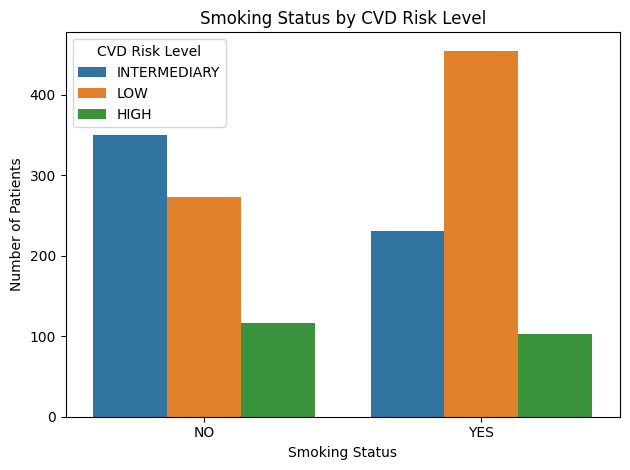

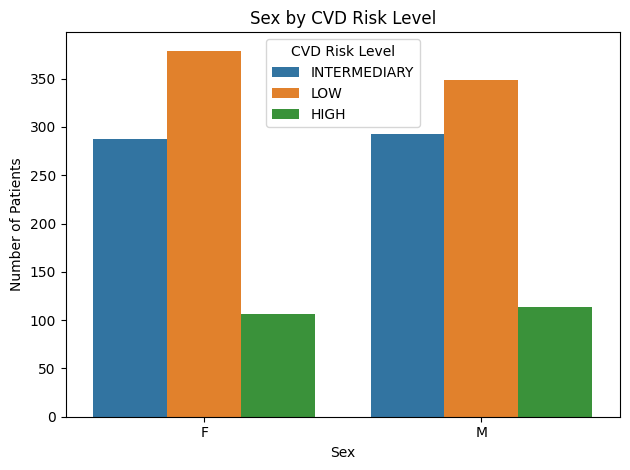

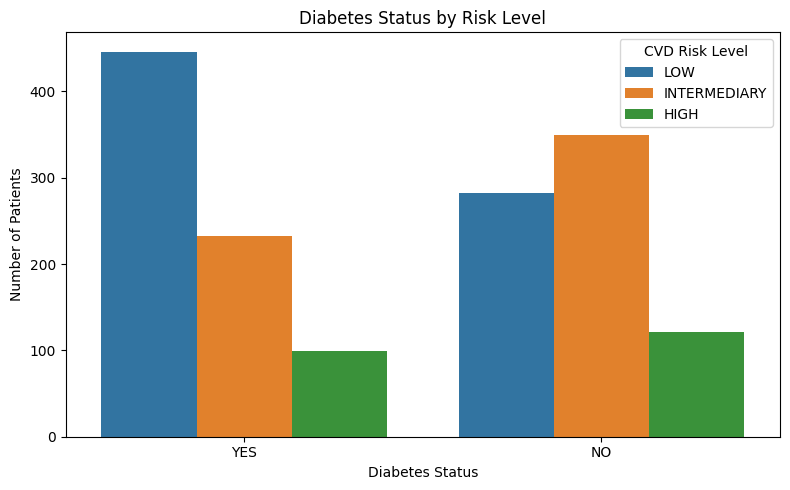

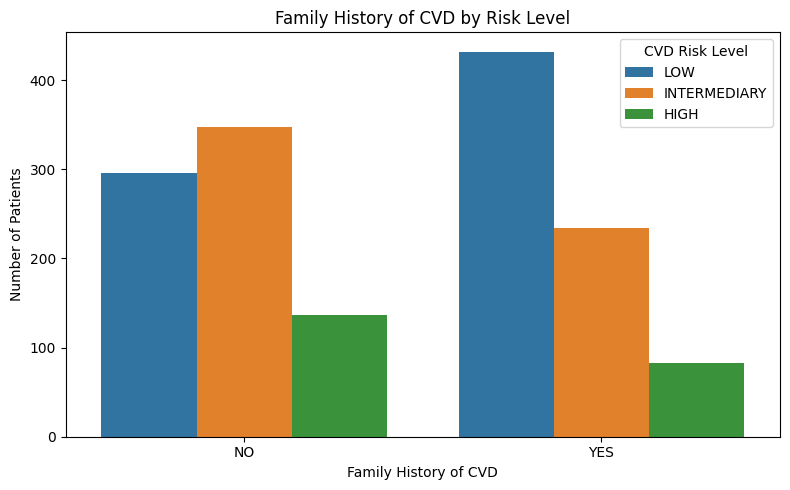

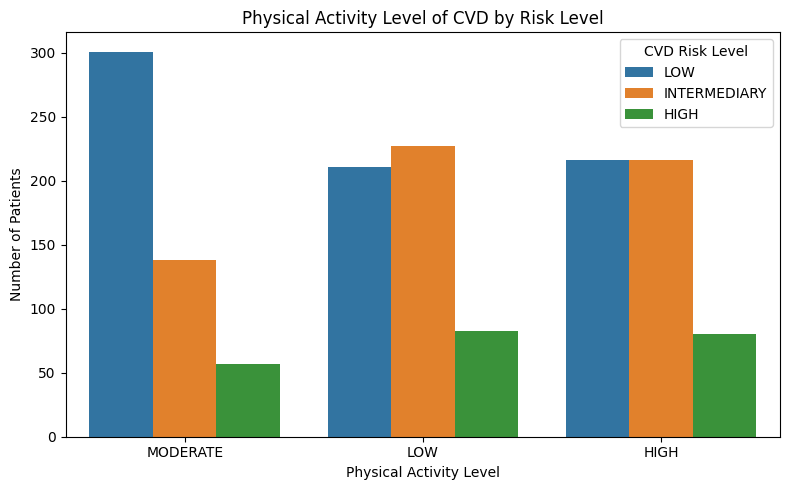

In [ ]:
# Smoking Status by CVD Risk Level
plot_df = df_clean.copy()

plot_df["Smoking Status"] = plot_df["Smoking Status"].map({
    0: "NO",
    1: "YES"
})

plot_df["CVD Risk Level"] = plot_df["CVD Risk Level"].map({
    0: "LOW",
    1: "INTERMEDIARY",
    2: "HIGH"
})

sns.countplot(
    data=plot_df,
    x="Smoking Status",
    hue="CVD Risk Level"
)

plt.title("Smoking Status by CVD Risk Level")
plt.xlabel("Smoking Status")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()


# Sex by CVD Risk Level
plot_df = df_clean.copy()

plot_df["Sex"] = plot_df["Sex"].map({
    0: "F",
    1: "M"
})

plot_df["CVD Risk Level"] = plot_df["CVD Risk Level"].map({
    0: "LOW",
    1: "INTERMEDIARY",
    2: "HIGH"
})

sns.countplot(
    data=plot_df,
    x="Sex",
    hue="CVD Risk Level"
)

plt.title("Sex by CVD Risk Level")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()


# Diabetes Status by CVD Risk Level
plot_df = df_clean.copy()

plot_df["CVD Risk Level"] = plot_df["CVD Risk Level"].map({
    0: "LOW",
    1: "INTERMEDIARY",
    2: "HIGH"
})

plot_df["Diabetes Status"] = plot_df["Diabetes Status"].map({
    0: "NO",
    1: "YES"
})

plt.figure(figsize=(8, 5))

sns.countplot(
    data=plot_df,
    x="Diabetes Status",
    hue="CVD Risk Level",
    hue_order=["LOW", "INTERMEDIARY", "HIGH"]
)

plt.title("Diabetes Status by Risk Level")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()


# Family History by CVD Risk Level
plot_df = df_clean.copy()

plot_df["CVD Risk Level"] = plot_df["CVD Risk Level"].map({
    0: "LOW",
    1: "INTERMEDIARY",
    2: "HIGH"
})

plot_df["Family History of CVD"] = plot_df["Family History of CVD"].map({
    0: "NO",
    1: "YES"
})

plt.figure(figsize=(8, 5))

sns.countplot(
    data=plot_df,
    x="Family History of CVD",
    hue="CVD Risk Level",
    hue_order=["LOW", "INTERMEDIARY", "HIGH"]
)

plt.title("Family History of CVD by Risk Level")
plt.xlabel("Family History of CVD")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()


# Physical Activity by CVD Risk Level
plot_df = df_clean.copy()

plot_df["CVD Risk Level"] = plot_df["CVD Risk Level"].map({
    0: "LOW",
    1: "INTERMEDIARY",
    2: "HIGH"
})

plot_df["Physical Activity Level"] = plot_df["Physical Activity Level"].map({
    0: "LOW",
    1: "MODERATE",
    2: "HIGH",
})

plt.figure(figsize=(8, 5))

sns.countplot(
    data=plot_df,
    x="Physical Activity Level",
    hue="CVD Risk Level",
    hue_order=["LOW", "INTERMEDIARY", "HIGH"]
)

plt.title("Physical Activity Level of CVD by Risk Level")
plt.xlabel("Physical Activity Level")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()


In [ ]:
# Numerical variables to test
numerical_features = [
    "Age",
    "Weight (kg)",
    "Height (m)",
    "BMI",
    "Abdominal Circumference (cm)",
    "Total Cholesterol (mg/dL)",
    "HDL (mg/dL)",
    "Estimated LDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Systolic BP",
    "Diastolic BP",
    "Waist-to-Height Ratio"
]

# Store results
results = []

# Run Kruskal-Wallis test for each numerical variable
for feature in numerical_features:

    # Get values for each CVD risk group
    low = df_clean.loc[
        df_clean["CVD Risk Level"] == 0,
        feature
    ].dropna()

    intermediary = df_clean.loc[
        df_clean["CVD Risk Level"] == 1,
        feature
    ].dropna()

    high = df_clean.loc[
        df_clean["CVD Risk Level"] == 2,
        feature
    ].dropna()

    # Make sure each group has observations
    if len(low) > 0 and len(intermediary) > 0 and len(high) > 0:

        statistic, p_value = kruskal(
            low,
            intermediary,
            high
        )

        results.append({
            "Feature": feature,
            "LOW n": len(low),
            "INTERMEDIARY n": len(intermediary),
            "HIGH n": len(high),
            "H Statistic": statistic,
            "p-value": p_value
        })

    else:
        results.append({
            "Feature": feature,
            "LOW n": len(low),
            "INTERMEDIARY n": len(intermediary),
            "HIGH n": len(high),
            "H Statistic": None,
            "p-value": None
        })

# Convert results to DataFrame
kruskal_results = pd.DataFrame(results)

# Sort by p-value
kruskal_results = kruskal_results.sort_values(
    "p-value",
    na_position="last"
)

kruskal_results

,Feature,LOW n,INTERMEDIARY n,HIGH n,H Statistic,p-value
7,Estimated LDL (mg/dL),728,581,220,67.765648,1.926977e-15
3,BMI,726,578,220,57.132564,3.924834e-13
6,HDL (mg/dL),728,581,220,46.045069,1.003322e-10
5,Total Cholesterol (mg/dL),728,581,220,43.626813,3.361692e-10
1,Weight (kg),728,581,220,26.814063,1.504528e-06
9,Systolic BP,728,581,220,15.684665,3.927518e-04
0,Age,728,581,220,15.228698,4.933216e-04
10,Diastolic BP,728,581,220,10.664283,4.833708e-03
8,Fasting Blood Sugar (mg/dL),728,581,220,6.703432,3.502420e-02
2,Height (m),727,577,219,4.905529,8.605537e-02


In [ ]:
# Statistical Significance
kruskal_results["Significant (p < 0.05)"] = (
    kruskal_results["p-value"] < 0.05
)

kruskal_results

,Feature,LOW n,INTERMEDIARY n,HIGH n,H Statistic,p-value,Significant (p < 0.05)
7,Estimated LDL (mg/dL),728,581,220,67.765648,1.926977e-15,True
3,BMI,726,578,220,57.132564,3.924834e-13,True
6,HDL (mg/dL),728,581,220,46.045069,1.003322e-10,True
5,Total Cholesterol (mg/dL),728,581,220,43.626813,3.361692e-10,True
1,Weight (kg),728,581,220,26.814063,1.504528e-06,True
9,Systolic BP,728,581,220,15.684665,3.927518e-04,True
0,Age,728,581,220,15.228698,4.933216e-04,True
10,Diastolic BP,728,581,220,10.664283,4.833708e-03,True
8,Fasting Blood Sugar (mg/dL),728,581,220,6.703432,3.502420e-02,True
2,Height (m),727,577,219,4.905529,8.605537e-02,False


In [ ]:
# Include FDR Correction (accounting for multiple comparisons)

# Remove rows where p-value could not be calculated
valid_results = kruskal_results["p-value"].notna()

adjusted_p_values = multipletests(
    kruskal_results.loc[valid_results, "p-value"],
    alpha=0.05,
    method="fdr_bh"
)

kruskal_results.loc[
    valid_results,
    "Adjusted p-value"
] = adjusted_p_values[1]

kruskal_results.loc[
    valid_results,
    "Significant after FDR"
] = adjusted_p_values[0]

kruskal_results

,Feature,LOW n,INTERMEDIARY n,HIGH n,H Statistic,p-value,Significant (p < 0.05),Adjusted p-value,Significant after FDR
7,Estimated LDL (mg/dL),728,581,220,67.765648,1.926977e-15,True,2.312373e-14,True
3,BMI,726,578,220,57.132564,3.924834e-13,True,2.354900e-12,True
6,HDL (mg/dL),728,581,220,46.045069,1.003322e-10,True,4.013287e-10,True
5,Total Cholesterol (mg/dL),728,581,220,43.626813,3.361692e-10,True,1.008508e-09,True
1,Weight (kg),728,581,220,26.814063,1.504528e-06,True,3.610866e-06,True
9,Systolic BP,728,581,220,15.684665,3.927518e-04,True,7.855036e-04,True
0,Age,728,581,220,15.228698,4.933216e-04,True,8.456943e-04,True
10,Diastolic BP,728,581,220,10.664283,4.833708e-03,True,7.250562e-03,True
8,Fasting Blood Sugar (mg/dL),728,581,220,6.703432,3.502420e-02,True,4.669894e-02,True
2,Height (m),727,577,219,4.905529,8.605537e-02,False,1.032664e-01,False


Implement Chi-Squared for categorical values

In [ ]:
# Identify categorical columns (excluding the target 'CVD Risk Level')
categorical_features = [
    "Sex",
    "Smoking Status",
    "Diabetes Status",
    "Physical Activity Level",
    "Family History of CVD",
    "Blood Pressure Category"
]

chi2_results = []

for feature in categorical_features:
    # Create a contingency table
    contingency_table = pd.crosstab(
        df_clean[feature],
        df_clean["CVD Risk Level"]
    )

    # Perform Chi-squared test
    chi2, p_value, _, _ = chi2_contingency(contingency_table)

    chi2_results.append({
        "Feature": feature,
        "Chi2 Statistic": chi2,
        "p-value": p_value
    })

# Convert results to DataFrame
chi2_results_df = pd.DataFrame(chi2_results)

# Sort by p-value
chi2_results_df = chi2_results_df.sort_values("p-value")

# Apply FDR correction
adjusted_p_values_chi2 = multipletests(
    chi2_results_df["p-value"],
    alpha=0.05,
    method="fdr_bh"
)

chi2_results_df["Adjusted p-value"] = adjusted_p_values_chi2[1]
chi2_results_df["Significant after FDR"] = adjusted_p_values_chi2[0]

chi2_results_df

,Feature,Chi2 Statistic,p-value,Adjusted p-value,Significant after FDR
1,Smoking Status,69.265232,9.104287e-16,5.462572e-15,True
2,Diabetes Status,62.314052,2.942223e-14,8.826669e-14,True
4,Family History of CVD,60.034926,9.195627e-14,1.839125e-13,True
3,Physical Activity Level,50.940082,2.297504e-10,3.446256e-10,True
5,Blood Pressure Category,24.838255,3.658181e-04,4.389817e-04,True
0,Sex,1.381360,5.012350e-01,5.012350e-01,False


# Train-Test Split

In [ ]:
X = df_clean.drop([
    "CVD Risk Level",
    "CVD Risk Score",
    "Height (cm)",
    "Blood Pressure (mmHg)",
    "Blood Pressure Category"
], axis=1)

y = df_clean["CVD Risk Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X.columns.tolist())

['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)']


# Feature Scaling

In [ ]:
scaler = StandardScaler()

# Explicitly drop all unwanted columns again to ensure they are removed from the cleaned sets
drop_columns_for_scaling = [
    'Height (cm)',
    'Blood Pressure (mmHg)',
    'Blood Pressure Category',

]

X_train_cleaned = X_train.drop(columns=drop_columns_for_scaling, errors='ignore')
X_test_cleaned = X_test.drop(columns=drop_columns_for_scaling, errors='ignore')

# Impute remaining NaN values with the median from the training set to prevent data leakage
for col in ['BMI']:
    if col in X_train_cleaned.columns:
        median_val = X_train_cleaned[col].median()
        # Correctly impute by reassigning the column to avoid chained assignment warnings
        X_train_cleaned.loc[:, col] = X_train_cleaned[col].fillna(median_val)
        X_test_cleaned.loc[:, col] = X_test_cleaned[col].fillna(median_val)

X_train_scaled = scaler.fit_transform(X_train_cleaned)
X_test_scaled = scaler.transform(X_test_cleaned)

In [ ]:
print(X_train_cleaned.columns.tolist())

['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)']


# Model Building

Logisitic Regression

In [ ]:
# Initialize SimpleImputer to handle any remaining NaN values in the scaled data
# The strategy is 'median' to be consistent with previous imputation attempts
imputer = SimpleImputer(strategy='median')

# Fit the imputer on the scaled training data and transform both training and test data
X_train_scaled_imputed = imputer.fit_transform(X_train_scaled)
X_test_scaled_imputed = imputer.transform(X_test_scaled)

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled_imputed, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled_imputed)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
print("Precision Score (weighted):", precision_score(y_test, y_pred, average='weighted'))
print("Recall Score (weighted):", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score (weighted):", f1_score(y_test, y_pred, average='weighted'))

# ROC AUC for multi-class classification (using 'ovr' strategy for consistency with a weighted average)
y_pred_proba = model.predict_proba(X_test_scaled_imputed)
print("ROC AUC Score (OvR, weighted):", roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted'))

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.71      0.67       146
           1       0.60      0.70      0.65       116
           2       0.50      0.09      0.15        44

    accuracy                           0.62       306
   macro avg       0.58      0.50      0.49       306
weighted avg       0.60      0.62      0.59       306


Confusion Matrix:
[[104  39   3]
 [ 34  81   1]
 [ 25  15   4]]

Accuracy Score: 0.6176470588235294
Precision Score (weighted): 0.6037691968402903
Recall Score (weighted): 0.6176470588235294
F1 Score (weighted): 0.5879610255481983
ROC AUC Score (OvR, weighted): 0.7219684257793114


Decision Tree

In [ ]:
# Initialize and train the Decision Tree model
# Using a random_state for reproducibility
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=100,   # maximum depth of the tree
    min_samples_split=5,  # minimum samples required to split an internal node
    min_samples_leaf=3  # minimum samples required to be at a leaf node
)
decision_tree_model.fit(X_train_scaled_imputed, y_train)

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test_scaled_imputed)

# Evaluate the Decision Tree model
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("Decision Tree Accuracy Score:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Precision Score (weighted):", precision_score(y_test, y_pred_dt, average='weighted'))
print("Decision Tree Recall Score (weighted):", recall_score(y_test, y_pred_dt, average='weighted'))
print("Decision Tree F1 Score (weighted):", f1_score(y_test, y_pred_dt, average='weighted'))

# ROC AUC for multi-class classification (using 'ovr' strategy)
y_pred_proba_dt = decision_tree_model.predict_proba(X_test_scaled_imputed)
print("Decision Tree ROC AUC Score (OvR, weighted):", roc_auc_score(y_test, y_pred_proba_dt, multi_class='ovr', average='weighted'))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.66      0.65       146
           1       0.54      0.53      0.54       116
           2       0.35      0.30      0.32        44

    accuracy                           0.56       306
   macro avg       0.51      0.50      0.50       306
weighted avg       0.56      0.56      0.56       306

Decision Tree Confusion Matrix:
[[97 37 12]
 [42 62 12]
 [15 16 13]]
Decision Tree Accuracy Score: 0.5620915032679739
Decision Tree Precision Score (weighted): 0.5554236237100687
Decision Tree Recall Score (weighted): 0.5620915032679739
Decision Tree F1 Score (weighted): 0.5581868901694609
Decision Tree ROC AUC Score (OvR, weighted): 0.6520129952509999


Random Forest

In [ ]:
# Using a random_state for reproducibility
random_forest_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,  # number of trees in the forest
    max_depth=10,      # maximum depth of the tree
    min_samples_leaf=5 # minimum number of samples required to be at a leaf node
)
random_forest_model.fit(X_train_scaled_imputed, y_train)

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test_scaled_imputed)

# Evaluate the Random Forest model
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("Random Forest Accuracy Score:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Precision Score (weighted):", precision_score(y_test, y_pred_rf, average='weighted'))
print("Random Forest Recall Score (weighted):", recall_score(y_test, y_pred_rf, average='weighted'))
print("Random Forest F1 Score (weighted):", f1_score(y_test, y_pred_rf, average='weighted'))

# ROC AUC for multi-class classification (using 'ovr' strategy)
y_pred_proba_rf = random_forest_model.predict_proba(X_test_scaled_imputed)
print("Random Forest ROC AUC Score (OvR, weighted):", roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr', average='weighted'))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.79      0.70       146
           1       0.60      0.63      0.61       116
           2       0.33      0.02      0.04        44

    accuracy                           0.62       306
   macro avg       0.52      0.48      0.45       306
weighted avg       0.58      0.62      0.57       306

Random Forest Confusion Matrix:
[[115  30   1]
 [ 42  73   1]
 [ 24  19   1]]
Random Forest Accuracy Score: 0.6176470588235294
Random Forest Precision Score (weighted): 0.577905011998258
Random Forest Recall Score (weighted): 0.6176470588235294
Random Forest F1 Score (weighted): 0.5742586136913368
Random Forest ROC AUC Score (OvR, weighted): 0.8006111285079185


Gradient Boosting

In [ ]:
# Using a random_state for reproducibility
gradient_boosting_model = GradientBoostingClassifier(
    random_state=42,
    n_estimators=100,  # Number of boosting stages
    learning_rate=0.1, # Step size shrinkage to prevent overfitting
    max_depth=3,       # Maximum depth of the individual regression estimators
    min_samples_leaf=1 # Minimum number of samples required to be at a leaf node
)
gradient_boosting_model.fit(X_train_scaled_imputed, y_train)

# Make predictions on the test set
y_pred_gb = gradient_boosting_model.predict(X_test_scaled_imputed)

# Evaluate the Gradient Boosting model
print("Gradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nGradient Boosting Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

print("\nGradient Boosting Accuracy Score:", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting Precision Score (weighted):", precision_score(y_test, y_pred_gb, average='weighted'))
print("Gradient Boosting Recall Score (weighted):", recall_score(y_test, y_pred_gb, average='weighted'))
print("Gradient Boosting F1 Score (weighted):", f1_score(y_test, y_pred_gb, average='weighted'))

# ROC AUC for multi-class classification (using 'ovr' strategy)
y_pred_proba_gb = gradient_boosting_model.predict_proba(X_test_scaled_imputed)
print("Gradient Boosting ROC AUC Score (OvR, weighted):", roc_auc_score(y_test, y_pred_proba_gb, multi_class='ovr', average='weighted'))

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.80      0.75       146
           1       0.65      0.70      0.68       116
           2       0.25      0.09      0.13        44

    accuracy                           0.66       306
   macro avg       0.54      0.53      0.52       306
weighted avg       0.62      0.66      0.63       306


Gradient Boosting Confusion Matrix:
[[117  21   8]
 [ 31  81   4]
 [ 18  22   4]]

Gradient Boosting Accuracy Score: 0.6601307189542484
Gradient Boosting Precision Score (weighted): 0.6198621176673804
Gradient Boosting Recall Score (weighted): 0.6601307189542484
Gradient Boosting F1 Score (weighted): 0.6328976034858388
Gradient Boosting ROC AUC Score (OvR, weighted): 0.799147408729127


XGBoost

In [ ]:
# Using a random_state for reproducibility
xgboost_model = XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y_train)),
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=100,      # Number of boosting rounds
    learning_rate=0.1,     # Step size shrinkage to prevent overfitting
    max_depth=3,           # Maximum depth of a tree
    subsample=0.8,         # Subsample ratio of the training instance
    colsample_bytree=0.8   # Subsample ratio of columns when constructing each tree
)
xgboost_model.fit(X_train_scaled_imputed, y_train)

# Make predictions on the test set
y_pred_xgb = xgboost_model.predict(X_test_scaled_imputed)

# Evaluate the XGBoost model
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("XGBoost Accuracy Score:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Precision Score (weighted):", precision_score(y_test, y_pred_xgb, average='weighted'))
print("XGBoost Recall Score (weighted):", recall_score(y_test, y_pred_xgb, average='weighted'))
print("XGBoost F1 Score (weighted):", f1_score(y_test, y_pred_xgb, average='weighted'))

# ROC AUC for multi-class classification (using 'ovr' strategy)
y_pred_proba_xgb = xgboost_model.predict_proba(X_test_scaled_imputed)
print("XGBoost ROC AUC Score (OvR, weighted):", roc_auc_score(y_test, y_pred_proba_xgb, multi_class='ovr', average='weighted'))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.81      0.75       146
           1       0.68      0.70      0.69       116
           2       0.26      0.11      0.16        44

    accuracy                           0.67       306
   macro avg       0.55      0.54      0.53       306
weighted avg       0.63      0.67      0.64       306

XGBoost Confusion Matrix:
[[118  19   9]
 [ 30  81   5]
 [ 19  20   5]]
XGBoost Accuracy Score: 0.6666666666666666
XGBoost Precision Score (weighted): 0.6308517124677374
XGBoost Recall Score (weighted): 0.6666666666666666
XGBoost F1 Score (weighted): 0.6427918716367534
XGBoost ROC AUC Score (OvR, weighted): 0.8028496380807579


# Comparison Table

In [ ]:
data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_gb), accuracy_score(y_test, y_pred_xgb)],
    'Precision': [
        precision_score(y_test, y_pred, average='weighted'),
        precision_score(y_test, y_pred_dt, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_gb, average='weighted'),
        precision_score(y_test, y_pred_xgb, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred_dt, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_gb, average='weighted'),
        recall_score(y_test, y_pred_xgb, average='weighted')
    ],
    'F1 Score': [
        f1_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred_dt, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_gb, average='weighted'),
        f1_score(y_test, y_pred_xgb, average='weighted')
    ]
}

model_results_df = pd.DataFrame(data)

# Set display options to show all columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

print(model_results_df)

# Reset display options to default to avoid affecting subsequent outputs
pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.617647   0.603769  0.617647  0.587961
1        Decision Tree  0.562092   0.555424  0.562092  0.558187
2        Random Forest  0.617647   0.577905  0.617647  0.574259
3    Gradient Boosting  0.660131   0.619862  0.660131  0.632898
4              XGBoost  0.666667   0.630852  0.666667  0.642792


# Feature Importance

Random Forest Feature Importance

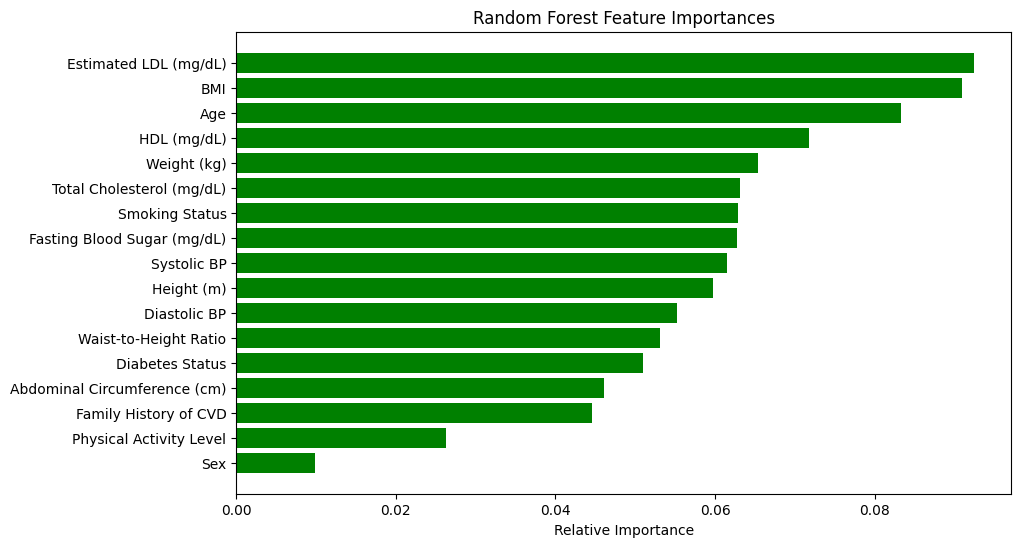

In [ ]:
feature_names_rf = X_train_cleaned.columns
importances_rf = random_forest_model.feature_importances_

# Sort feature importances in ascending order
sorted_indices_rf = np.argsort(importances_rf)

# Create horizontal bar plot
plt.figure(figsize=(10, 6))
plt.title('Random Forest Feature Importances')
plt.barh(range(len(sorted_indices_rf)), importances_rf[sorted_indices_rf], color='green', align='center')
plt.yticks(range(len(sorted_indices_rf)), [feature_names_rf[i] for i in sorted_indices_rf])
plt.xlabel('Relative Importance')
plt.show()

XGBoost Feature Importance

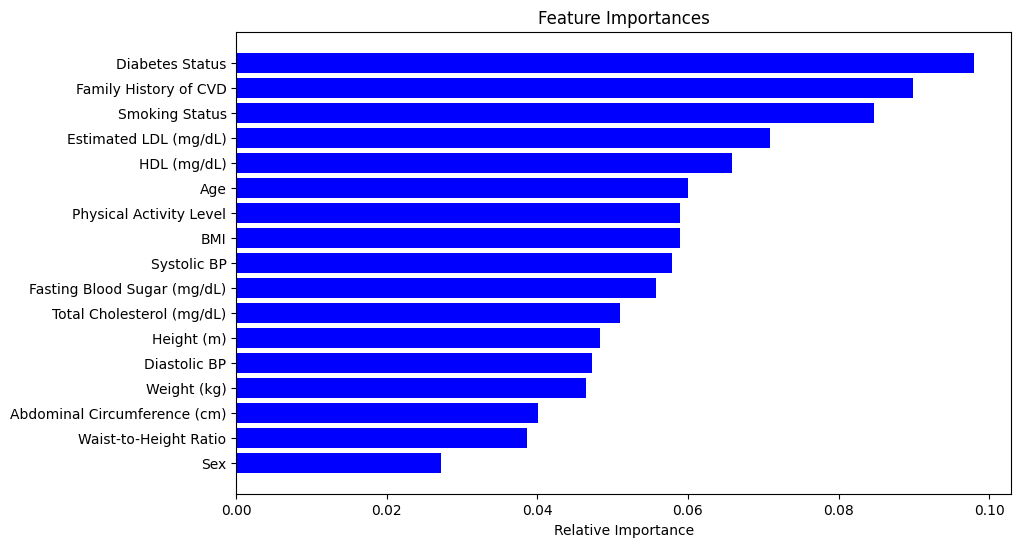

In [ ]:
feature_names = X_train_cleaned.columns
importances = xgboost_model.feature_importances_
indices = np.argsort(importances)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()